In [15]:
! uv pip install ../.[training] --no-deps

Using Python 3.12.10 environment at: /home/dmp131/anaconda3/envs/cshark
Resolved 1 package in 3ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshark @ file:///home/dmp131/C.Shark               
Prepared 1 package

In [2]:
from cshark.inference.utils import model_utils

model_path = '/mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/H1_H7_H9_snps_ctcf_recon.ckpt'
num_genomic_features = 2
image_scale = 512
model = model_utils.load_default(model_path, num_genomic_features=num_genomic_features, mat_size=image_scale, 
                                 seq_filter_size=15, recon_1d=True)
model.eval()
print(model)

MultiTaskConvTransModel(
  (encoder): EncoderSplit(
    (conv_start_seq): Sequential(
      (0): Conv1d(5, 16, kernel_size=(15,), stride=(2,), padding=(1,))
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (conv_start_epi): Sequential(
      (0): Conv1d(2, 16, kernel_size=(5,), stride=(2,), padding=(1,))
      (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (res_blocks_seq): Sequential(
      (0): ConvBlock(
        (scale): Sequential(
          (0): Conv1d(16, 16, kernel_size=(5,), stride=(2,), padding=(2,))
          (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
        (res): Sequential(
          (0): Conv1d(16, 16, kernel_size=(5,), stride=(1,), padding=(2,))
          (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
   

In [3]:
# get the conv filters from the conv_start_seq DNA sequence processing layer
conv_start_seq = model.encoder.conv_start_seq
print(conv_start_seq)

Sequential(
  (0): Conv1d(5, 16, kernel_size=(15,), stride=(2,), padding=(1,))
  (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)


In [4]:
# get the filters from the conv_start_seq layer
conv_start_seq_weights = conv_start_seq[0].weight
print(conv_start_seq_weights.shape)  # should be (num_filters, num_genomic_features, kernel_size)

torch.Size([16, 5, 15])


In [12]:
# visualize the filters
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

def visualize_filters(filters, num_genomic_features, kernel_size):
    num_filters = filters.shape[0]
    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 2))
    for i in range(num_filters):
        ax = axes[i]
        sns.heatmap(filters[i].detach().cpu().numpy().squeeze(), ax=ax, cmap='viridis', cbar=False, center=0)
        ax.set_title(f'Filter {i}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
from pyjaspar import jaspardb

jdb_obj = jaspardb(release='JASPAR2024')
motifs = jdb_obj.fetch_motifs(
        collection = ['CORE'],
        tax_group = ['Vertebrates'],
        species=['9606'],
        all_versions = False)
for i, motif in enumerate(motifs):
    print(motif.name)
    print(motif.counts)
    matrix = motif.counts.normalize()
    print(matrix.values())
    print(matrix['A'])
    break

PAX6
        0      1      2      3      4      5      6      7      8      9     10     11     12     13
A:   2.00   2.00   4.00  39.00   3.00   1.00   1.00  21.00   1.00   2.00  36.00  11.00   1.00   1.00
C:   4.00   2.00  26.00   2.00  34.00   0.00  37.00   2.00   4.00  14.00   0.00  11.00   5.00   0.00
G:   4.00   0.00   1.00   1.00   1.00  41.00   4.00   2.00   1.00  25.00   6.00  13.00   3.00  17.00
T:  33.00  39.00  12.00   1.00   5.00   1.00   1.00  18.00  37.00   2.00   1.00   8.00  34.00  25.00

dict_values([(0.046511627906976744, 0.046511627906976744, 0.09302325581395349, 0.9069767441860465, 0.06976744186046512, 0.023255813953488372, 0.023255813953488372, 0.4883720930232558, 0.023255813953488372, 0.046511627906976744, 0.8372093023255814, 0.2558139534883721, 0.023255813953488372, 0.023255813953488372), (0.09302325581395349, 0.046511627906976744, 0.6046511627906976, 0.046511627906976744, 0.7906976744186046, 0.0, 0.8604651162790697, 0.046511627906976744, 0.09302325581395349, 0.

In [7]:
for motif in motifs:
    if motif.name == 'CTCF':
        print(motif.name)
        print(motif.counts)
        matrix = motif.counts.normalize()
        print(matrix.values())
        print(matrix['A'])
        break

CTCF
        0      1      2      3      4      5      6      7      8      9     10     11     12     13     14
A: 281.00  56.00   8.00 744.00  40.00 107.00 851.00   5.00 333.00  54.00  12.00  56.00 104.00 372.00  82.00
C:  49.00 800.00 903.00  13.00 528.00 433.00  11.00   0.00   3.00  12.00   0.00   8.00 733.00  13.00 482.00
G: 449.00  21.00   0.00  65.00 334.00  48.00  32.00 903.00 566.00 504.00 890.00 775.00   5.00 507.00 307.00
T: 134.00  36.00   2.00  91.00  11.00 324.00  18.00   3.00   9.00 341.00   8.00  71.00  67.00  17.00  37.00

dict_values([(0.307776560788609, 0.06133625410733844, 0.008762322015334063, 0.8148959474260679, 0.04381161007667032, 0.11732456140350878, 0.9331140350877193, 0.005488474204171241, 0.36553238199780463, 0.059275521405049394, 0.013186813186813187, 0.06153846153846154, 0.11441144114411442, 0.40924092409240925, 0.09030837004405286), (0.05366922234392114, 0.8762322015334063, 0.9890470974808324, 0.014238773274917854, 0.5783132530120482, 0.47478070175438597,

In [9]:
import logomaker
from matplotlib import axis
import pandas as pd
from scipy.signal import correlate2d
from scipy.stats import norm

mouse_tfs = ['SP5', 'SP4', 'SP3', 'KLF3', 'ZBTB17', 'KLF15', 'SP1', 'MAZ', 'KLF6',
             'SP2', 'ZNF281', 'SALL1', 'ZNF148', 'WT1', 'EGR2', 'KLF5', 'RREB1',
             'KLF1', 'E2F4', 'EGR4', 'CTCF', 'CTCFL', 'Zic2', 'OCT4', 
             'TBX4', 'ZNF502', 'KLF14', 'BHA15', 'YY1']
filter_to_mouse_motifs = True


def visualize_filters_with_logomaker(filters, num_genomic_features, kernel_size):
    num_filters = filters.shape[0]
    top_motifs = []
    for i in range(num_filters):
        filter_weights = filters[i].detach().cpu().numpy().squeeze()
        if num_genomic_features == 1:
            filter_weights = np.expand_dims(filter_weights, axis=0)  # Add a channel dimension if needed
        logo_df = pd.DataFrame(filter_weights.T, columns=['A', 'T', 'C', 'G', 'N'])
        filter_mat = logo_df[['A', 'C', 'G', 'T', 'N']].values  # Ensure the order is ACGT
        filter_mat = np.clip(filter_mat, 0, None)  # clip negative values to zero
        max_corr = -np.inf
        best_motif = None
        best_motif_pos = None
        best_mat = None
        corrs = []
        for motif in motifs:
            matrix_dict = motif.counts.normalize()  # ACGT 
            matrix = []
            for base in ['A', 'C', 'G', 'T', 'N']:
                if base in matrix_dict:
                    matrix.append(list(matrix_dict[base]))
                else:
                    matrix.append([0] * len(matrix_dict['A']))
            matrix = np.array(matrix).T
            if matrix.shape[0] > 20:  # skip very long motifs
                continue
            # corr = correlate2d(filter_mat, matrix, mode='same')
            # print(filter_mat.shape, matrix.shape, corr.shape)
            # corrs.append(corr.max())
            corr = []
            if filter_mat.shape[0] > matrix.shape[0]:
                for j in range(filter_mat.shape[0] - matrix.shape[0] + 1):
                    corr.append(np.corrcoef(filter_mat[j:j + matrix.shape[0], :].flatten(), matrix.flatten())[0, 1])
            else:
                for j in range(matrix.shape[0] - filter_mat.shape[0] + 1):
                    corr.append(np.corrcoef(filter_mat.flatten(), matrix[j:j + filter_mat.shape[0], :].flatten())[0, 1])
            corr = np.array(corr)
            if corr.max() > max_corr and (not filter_to_mouse_motifs or motif.name in mouse_tfs):
                max_corr = corr.max()
                best_motif = motif.name
                best_motif_pos = int(np.argmax(corr))
                best_mat = matrix
            # known_motifs = ['CTCF', 'CTCFL', 'Zic2', 'OCT4', 'TBX4', 'ZNF502', 'KLF14', 'BHA15', 'YY1']
            # known_motifs = ['CTCF', 'CTCFL']
            # if corr.max() > 0.4 and motif.name in known_motifs:
            #     print(f'Found {motif.name} motif at position {best_motif_pos} with correlation {corr.max():.2f}')
            #     max_corr = corr.max()
            #     best_motif = motif.name
            #     best_motif_pos = int(np.argmax(corr))
            #     best_mat = matrix
            #     break
        print(f'Best motif for filter {i}: {best_motif} with correlation {max_corr:.2f}')
        top_motifs.append(best_motif)



        logo = logomaker.Logo(logo_df, 
                              shade_below=.5,
                              fade_below=.5,
                              figsize=(4, 2),
                              color_scheme='classic')
        # style using Logo methods
        logo.style_spines(visible=False)
        logo.style_spines(spines=['left', 'bottom'], visible=True)
        logo.style_xticks(rotation=90, fmt='%d', anchor=0)
        logo.ax.set_title(f'{i} - Closest motif: {best_motif} (corr: {max_corr:.2f})')
        if filter_mat.shape[0] > best_mat.shape[0]:  # highlight the motif region
            print(f'Filter {i} has length {filter_mat.shape[0]}, best motif {best_motif} has length {best_mat.shape[0]}')
            print(f'Highlighting motif position {best_motif_pos} to {best_motif_pos + best_mat.shape[0] - 1}')
            logo.highlight_position_range(pmin=best_motif_pos, pmax=best_motif_pos + best_mat.shape[0] - 1, color='lightcyan')

        plt.show()

        # plt.hist(corrs, bins=20)
        # plt.title(f'Correlation distribution for filter {i}')
        # plt.xlabel('Correlation')
        # plt.ylabel('Frequency')
        # plt.show()
    return top_motifs

Best motif for filter 0: SP5 with correlation 0.57


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 0 has length 15, best motif SP5 has length 6
Highlighting motif position 8 to 13


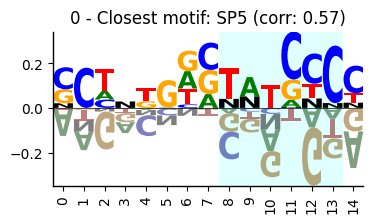

Best motif for filter 1: SP5 with correlation 0.45


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 1 has length 15, best motif SP5 has length 6
Highlighting motif position 7 to 12


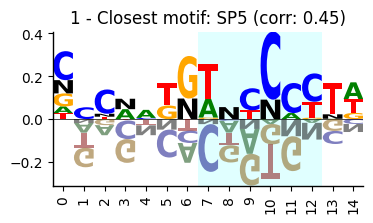

Best motif for filter 2: MAZ with correlation 0.45


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 2 has length 15, best motif MAZ has length 8
Highlighting motif position 7 to 14


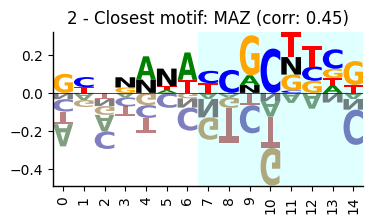

Best motif for filter 3: ZBTB17 with correlation 0.27


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 3 has length 15, best motif ZBTB17 has length 8
Highlighting motif position 2 to 9


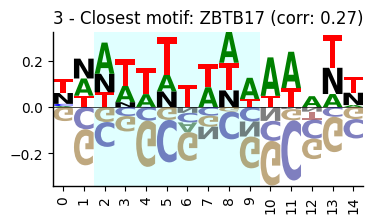

Best motif for filter 4: TBX4 with correlation 0.49


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 4 has length 15, best motif TBX4 has length 8
Highlighting motif position 6 to 13


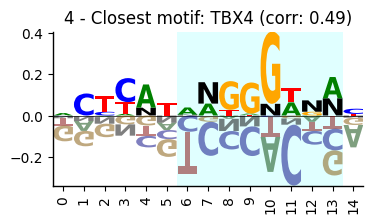

Best motif for filter 5: KLF15 with correlation 0.50


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 5 has length 15, best motif KLF15 has length 8
Highlighting motif position 1 to 8


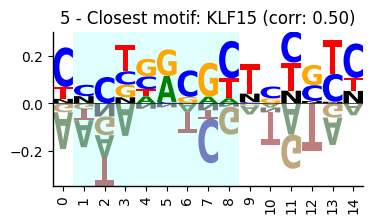

Best motif for filter 6: SP2 with correlation 0.64


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 6 has length 15, best motif SP2 has length 9
Highlighting motif position 5 to 13


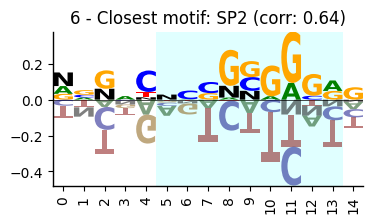

Best motif for filter 7: TBX4 with correlation 0.29


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 7 has length 15, best motif TBX4 has length 8
Highlighting motif position 4 to 11


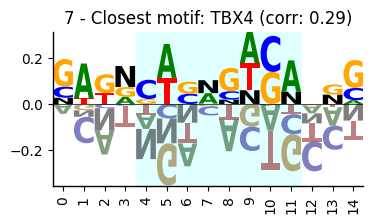

Best motif for filter 8: CTCFL with correlation 0.52


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 8 has length 15, best motif CTCFL has length 8
Highlighting motif position 1 to 8


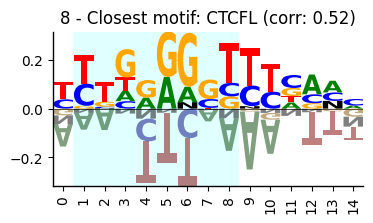

Best motif for filter 9: TBX4 with correlation 0.48


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 9 has length 15, best motif TBX4 has length 8
Highlighting motif position 2 to 9


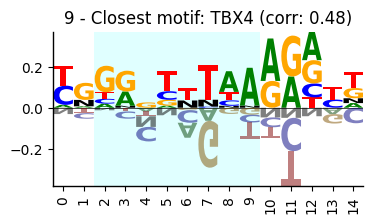

Best motif for filter 10: SP5 with correlation 0.87


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 10 has length 15, best motif SP5 has length 6
Highlighting motif position 6 to 11


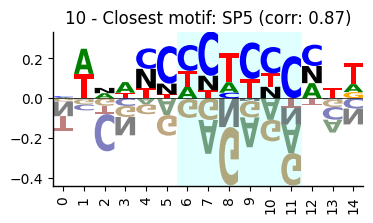

Best motif for filter 11: CTCFL with correlation 0.65


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 11 has length 15, best motif CTCFL has length 8
Highlighting motif position 0 to 7


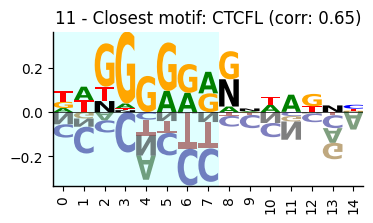

Best motif for filter 12: CTCFL with correlation 0.61


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 12 has length 15, best motif CTCFL has length 8
Highlighting motif position 3 to 10


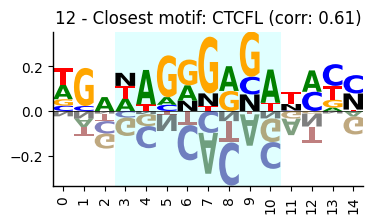

Best motif for filter 13: SP5 with correlation 0.71


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 13 has length 15, best motif SP5 has length 6
Highlighting motif position 0 to 5


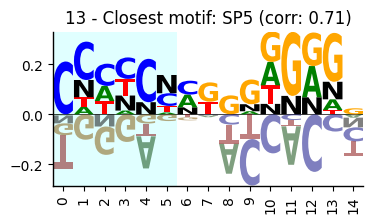

Best motif for filter 14: SP5 with correlation 0.48


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 14 has length 15, best motif SP5 has length 6
Highlighting motif position 0 to 5


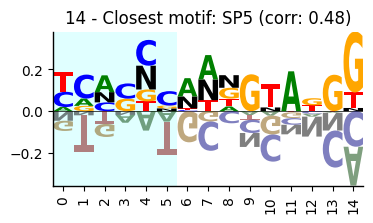

Best motif for filter 15: CTCFL with correlation 0.60


/home/dmp131/anaconda3/envs/cshark/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))


Filter 15 has length 15, best motif CTCFL has length 8
Highlighting motif position 6 to 13


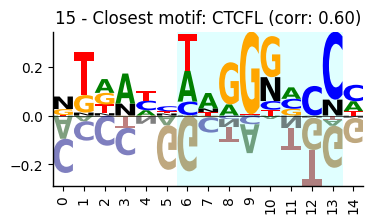

['SP5',
 'SP5',
 'MAZ',
 'ZBTB17',
 'TBX4',
 'KLF15',
 'SP2',
 'TBX4',
 'CTCFL',
 'TBX4',
 'SP5',
 'CTCFL',
 'CTCFL',
 'SP5',
 'SP5',
 'CTCFL']

In [10]:
visualize_filters_with_logomaker(conv_start_seq_weights, num_genomic_features, conv_start_seq_weights.shape[2])

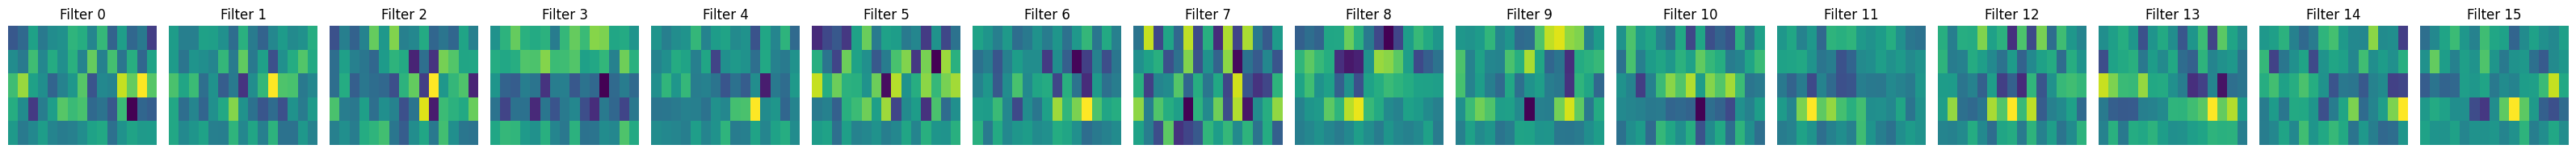

In [13]:
visualize_filters(conv_start_seq_weights, num_genomic_features, conv_start_seq_weights.shape[2])

In [14]:
# get the conv filters from the conv_start_epi DNA sequence processing layer
conv_start_epi = model.encoder.conv_start_epi
print(conv_start_epi)
# get the filters from the conv_start_seq layer
conv_start_epi_weights = conv_start_epi[0].weight
print(conv_start_epi_weights.shape)  # should be (num_filters, num_genomic_features, kernel_size)

Sequential(
  (0): Conv1d(2, 16, kernel_size=(5,), stride=(2,), padding=(1,))
  (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
)
torch.Size([16, 2, 5])


In [15]:
def visualize_kernels(filters, num_genomic_features, kernel_size):
    num_filters = filters.shape[0]
    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 2))
    for i in range(num_filters):
        ax = axes[i]
        kernel = filters[i][0].detach().cpu().numpy().squeeze()
        ax.plot(kernel)
        ax.set_title(f'Filter {i}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

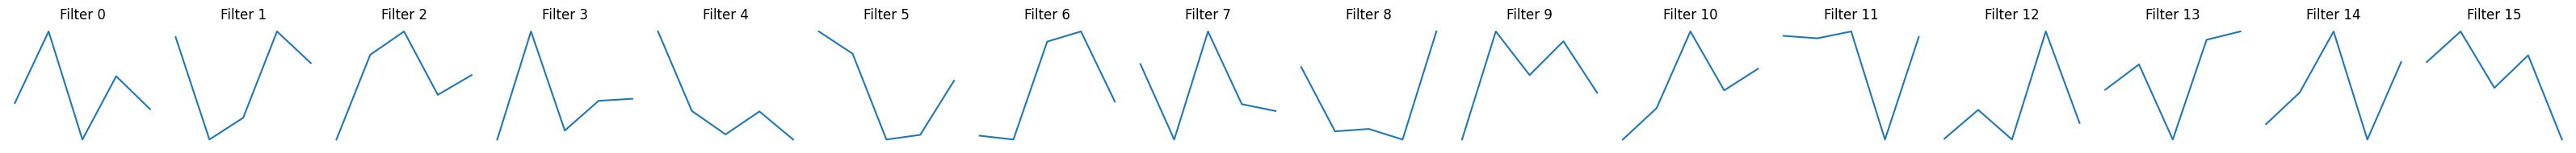

In [16]:
visualize_kernels(conv_start_epi_weights, num_genomic_features, conv_start_epi_weights.shape[2])